In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading Processed Datasets

In [2]:
df = pd.read_csv('../../data/processed/cleaned_lending-club-car-loan.csv')

In [3]:
df.head()

,Unnamed: 0,int_rate,loan_amnt,term,installment,annual_inc,verification_status,emp_length,dti,revol_util,...,loan_to_income,credit_score_norm,delinquency,log_delinquency,log_loan_amount,log_installment,log_income,log_credit_history_length,log_inquiries,inquiries
0,0,13.99,3600.0,36,123.03,55000.0,Not Verified,10.0,5.91,29.7,...,0.065453,0.752222,0.0,0.000000,8.188967,4.820523,10.915107,3.163566,0.693147,1.0
1,1,11.99,24700.0,36,820.28,65000.0,Not Verified,10.0,16.06,19.2,...,0.379994,0.796667,1.0,0.693147,10.114599,6.710864,11.082158,3.307739,1.609438,4.0
2,2,10.78,20000.0,60,432.66,63000.0,Not Verified,10.0,10.78,56.2,...,0.317455,0.774444,0.0,0.000000,9.903538,6.072261,11.050906,3.282969,0.000000,0.0
3,4,22.45,10400.0,60,289.91,104433.0,Source Verified,3.0,25.37,64.5,...,0.099584,0.774444,1.0,0.693147,9.249657,5.673014,11.556311,3.361231,1.386294,3.0
4,5,13.44,11950.0,36,405.18,34000.0,Source Verified,4.0,10.20,68.4,...,0.351460,0.768889,0.0,0.000000,9.388570,6.006796,10.434145,3.676266,0.000000,0.0


In [4]:
df.shape

(1373508, 29)

In [5]:
df_original = df.copy()

In [6]:
df["verification_status"] = df["verification_status"].astype("category")
df["purpose"] = df["purpose"].astype("category")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373508 entries, 0 to 1373507
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype   
---  ------                     --------------    -----   
 0   Unnamed: 0                 1373508 non-null  int64   
 1   int_rate                   1373508 non-null  float64 
 2   loan_amnt                  1373508 non-null  float64 
 3   term                       1373508 non-null  int64   
 4   installment                1373508 non-null  float64 
 5   annual_inc                 1373508 non-null  float64 
 6   verification_status        1373508 non-null  category
 7   emp_length                 1373508 non-null  float64 
 8   dti                        1373508 non-null  float64 
 9   revol_util                 1373508 non-null  float64 
 10  revol_bal                  1373508 non-null  float64 
 11  total_acc                  1373508 non-null  float64 
 12  open_acc                   1373508 non-null  float64 
 1

In [8]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [9]:
df.describe()

,int_rate,loan_amnt,term,installment,annual_inc,emp_length,dti,revol_util,revol_bal,total_acc,...,loan_to_income,credit_score_norm,delinquency,log_delinquency,log_loan_amount,log_installment,log_income,log_credit_history_length,log_inquiries,inquiries
count,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,...,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06,1.373508e+06
mean,1.328534e+01,1.445720e+04,4.186296e+01,4.389718e+02,7.628202e+04,5.630152e+00,1.830763e+01,5.177206e+01,1.624851e+04,2.494231e+01,...,2.197193e-01,7.756554e-01,3.185653e-01,1.738581e-01,9.369440e+00,5.896020e+00,1.108087e+01,3.298559e+00,3.803842e-01,6.615564e-01
std,4.787062e+00,8.742497e+03,1.031197e+01,2.621425e+02,7.026271e+04,3.832357e+00,1.132211e+01,2.453097e+01,2.242656e+04,1.200980e+01,...,1.105201e+00,3.534180e-02,8.798839e-01,3.861987e-01,6.970657e-01,6.561547e-01,5.285932e-01,2.614596e-01,4.775294e-01,9.586877e-01
min,5.310000e+00,5.000000e+02,3.600000e+01,4.930000e+00,1.600000e+01,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,...,1.714285e-04,6.800000e-01,0.000000e+00,0.000000e+00,6.216606e+00,1.780024e+00,2.833213e+00,2.440559e+00,0.000000e+00,0.000000e+00
25%,9.750000e+00,8.000000e+03,3.600000e+01,2.488800e+02,4.576000e+04,2.000000e+00,1.179000e+01,3.340000e+01,5.926000e+03,1.600000e+01,...,1.249969e-01,7.466667e-01,0.000000e+00,0.000000e+00,8.987322e+00,5.520981e+00,1.073119e+01,3.123993e+00,0.000000e+00,0.000000e+00
50%,1.279000e+01,1.200000e+04,3.600000e+01,3.754300e+02,6.500000e+04,6.000000e+00,1.763000e+01,5.210000e+01,1.111700e+04,2.300000e+01,...,1.999956e-01,7.688889e-01,0.000000e+00,0.000000e+00,9.392745e+00,5.930732e+00,1.108216e+01,3.282969e+00,0.000000e+00,0.000000e+00
75%,1.602000e+01,2.000000e+04,3.600000e+01,5.817700e+02,9.000000e+04,1.000000e+01,2.408000e+01,7.070000e+01,1.973600e+04,3.200000e+01,...,2.916606e-01,7.911111e-01,0.000000e+00,0.000000e+00,9.903538e+00,6.367793e+00,1.140758e+01,3.462992e+00,6.931472e-01,1.000000e+00
max,3.099000e+01,4.000000e+04,6.000000e+01,1.719830e+03,1.099920e+07,1.000000e+01,9.990000e+02,8.923000e+02,2.904836e+06,1.760000e+02,...,8.000000e+02,9.416667e-01,3.900000e+01,3.688879e+00,1.059666e+01,7.450562e+00,1.243719e+01,4.532982e+00,3.526361e+00,3.300000e+01


In [10]:
df.columns

Index(['int_rate', 'loan_amnt', 'term', 'installment', 'annual_inc',
       'verification_status', 'emp_length', 'dti', 'revol_util', 'revol_bal',
       'total_acc', 'open_acc', 'pub_rec', 'purpose', 'target', 'fico_score',
       'credit_history_length', 'dti_computed', 'loan_to_income',
       'credit_score_norm', 'delinquency', 'log_delinquency',
       'log_loan_amount', 'log_installment', 'log_income',
       'log_credit_history_length', 'log_inquiries', 'inquiries'],
      dtype='object')

In [11]:
numeric_features = [
    'int_rate','loan_amnt','term','installment','annual_inc',
    'emp_length','dti', 'revol_util', 'revol_bal','total_acc',
    'open_acc','pub_rec','target','fico_score','credit_history_length',
    'dti_computed', 'loan_to_income','credit_score_norm','delinquency',
    'log_delinquency','log_loan_amount','log_installment','log_income',
    'log_credit_history_length', 'log_inquiries', 'inquiries'
]
categorical_features = [
    'verification_status',
    'purpose'
]

In [12]:
df[categorical_features].nunique()

verification_status     3
purpose                14
dtype: int64

In [13]:
df[numeric_features].isnull().sum()

int_rate                     0
loan_amnt                    0
term                         0
installment                  0
annual_inc                   0
emp_length                   0
dti                          0
revol_util                   0
revol_bal                    0
total_acc                    0
open_acc                     0
pub_rec                      0
target                       0
fico_score                   0
credit_history_length        0
dti_computed                 0
loan_to_income               0
credit_score_norm            0
delinquency                  0
log_delinquency              0
log_loan_amount              0
log_installment              0
log_income                   0
log_credit_history_length    0
log_inquiries                0
inquiries                    0
dtype: int64

In [14]:
np.isinf(df[numeric_features]).any()

int_rate                     False
loan_amnt                    False
term                         False
installment                  False
annual_inc                   False
emp_length                   False
dti                          False
revol_util                   False
revol_bal                    False
total_acc                    False
open_acc                     False
pub_rec                      False
target                       False
fico_score                   False
credit_history_length        False
dti_computed                 False
loan_to_income               False
credit_score_norm            False
delinquency                  False
log_delinquency              False
log_loan_amount              False
log_installment              False
log_income                   False
log_credit_history_length    False
log_inquiries                False
inquiries                    False
dtype: bool

In [15]:
df.isna().any()

int_rate                     False
loan_amnt                    False
term                         False
installment                  False
annual_inc                   False
verification_status          False
emp_length                   False
dti                          False
revol_util                   False
revol_bal                    False
total_acc                    False
open_acc                     False
pub_rec                      False
purpose                      False
target                       False
fico_score                   False
credit_history_length        False
dti_computed                 False
loan_to_income               False
credit_score_norm            False
delinquency                  False
log_delinquency              False
log_loan_amount              False
log_installment              False
log_income                   False
log_credit_history_length    False
log_inquiries                False
inquiries                    False
dtype: bool

# Distribution of Key Features

In [16]:
df["target"].value_counts(normalize=True)

target
0    0.785166
1    0.214834
Name: proportion, dtype: float64

In [17]:
skewness = df[numeric_features].skew().sort_values(ascending=False)
print(f"All numeric feature skewness: {skewness}")

All numeric feature skewness: loan_to_income               546.227342
dti_computed                 538.175496
annual_inc                    46.736583
dti                           27.321725
revol_bal                     13.672153
pub_rec                       11.879492
delinquency                    5.633380
log_delinquency                2.328942
inquiries                      2.015033
target                         1.388661
open_acc                       1.297317
fico_score                     1.286532
credit_score_norm              1.286532
term                           1.190277
credit_history_length          1.012045
installment                    1.005016
total_acc                      0.959088
log_inquiries                  0.829138
loan_amnt                      0.780779
int_rate                       0.716733
log_credit_history_length      0.160740
revol_util                    -0.035901
log_income                    -0.077446
emp_length                    -0.145318
log_instal

loan_to_income:               546.227342
dti_computed:                 538.175496
annual_inc:                    46.736583
dti:                           27.321725
revol_bal:                     13.672153
pub_rec:                       11.879492
delinquency:                    5.633380
log_delinquency:                2.328942

In [18]:
df['loan_to_income'] = df['loan_to_income'].clip(upper=5)

In [19]:
df['log_loan_to_income'] = np.log1p(df['loan_to_income'])
df.drop(columns=['loan_to_income'], inplace=True)

In [20]:
df['dti'] = df['dti'].clip(lower=-0.999, upper=50)
df['log_dti'] = np.log1p(df['dti'])
df.drop(columns=['dti', 'dti_computed'], inplace=True)

In [21]:
df['annual_inc'] = df['annual_inc'].clip(upper=df['annual_inc'].quantile(0.99))
df['log_income'] = np.log1p(df['annual_inc'])

In [22]:
df['revol_bal'] = np.log1p(df['revol_bal'])

In [23]:
df.drop(columns=['delinquency', 'pub_rec'], inplace=True)

In [24]:
numeric_features = [
    'int_rate', 'loan_amnt', 'term', 'installment', 'log_income',
    'emp_length', 'revol_util', 'revol_bal', 'total_acc',
    'open_acc', 'target', 'fico_score', 'credit_history_length',
    'log_loan_to_income', 'credit_score_norm',
    'log_delinquency', 'log_loan_amount', 'log_installment',
    'log_credit_history_length', 'log_inquiries', 'inquiries'
]

In [25]:
np.isinf(df[numeric_features]).any()

int_rate                     False
loan_amnt                    False
term                         False
installment                  False
log_income                   False
emp_length                   False
revol_util                   False
revol_bal                    False
total_acc                    False
open_acc                     False
target                       False
fico_score                   False
credit_history_length        False
log_loan_to_income           False
credit_score_norm            False
log_delinquency              False
log_loan_amount              False
log_installment              False
log_credit_history_length    False
log_inquiries                False
inquiries                    False
dtype: bool

In [26]:
skewness = df[numeric_features].skew().sort_values(ascending=False)
print(f"All numeric feature skewness: {skewness}")

All numeric feature skewness: log_delinquency              2.328942
inquiries                    2.015033
log_loan_to_income           1.459280
target                       1.388661
open_acc                     1.297317
fico_score                   1.286532
credit_score_norm            1.286532
term                         1.190277
credit_history_length        1.012045
installment                  1.005016
total_acc                    0.959088
log_inquiries                0.829138
loan_amnt                    0.780779
int_rate                     0.716733
log_credit_history_length    0.160740
revol_util                  -0.035901
log_income                  -0.077446
emp_length                  -0.145318
log_installment             -0.598026
log_loan_amount             -0.654607
revol_bal                   -2.661472
dtype: float64


In [27]:
df.columns

Index(['int_rate', 'loan_amnt', 'term', 'installment', 'annual_inc',
       'verification_status', 'emp_length', 'revol_util', 'revol_bal',
       'total_acc', 'open_acc', 'purpose', 'target', 'fico_score',
       'credit_history_length', 'credit_score_norm', 'log_delinquency',
       'log_loan_amount', 'log_installment', 'log_income',
       'log_credit_history_length', 'log_inquiries', 'inquiries',
       'log_loan_to_income', 'log_dti'],
      dtype='object')

In [28]:
features = [col for col in df.columns if col != "target"]
target = "target"

In [29]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373508 entries, 0 to 1373507
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype   
---  ------                     --------------    -----   
 0   int_rate                   1373508 non-null  float64 
 1   loan_amnt                  1373508 non-null  float64 
 2   term                       1373508 non-null  int64   
 3   installment                1373508 non-null  float64 
 4   annual_inc                 1373508 non-null  float64 
 5   verification_status        1373508 non-null  category
 6   emp_length                 1373508 non-null  float64 
 7   revol_util                 1373508 non-null  float64 
 8   revol_bal                  1373508 non-null  float64 
 9   total_acc                  1373508 non-null  float64 
 10  open_acc                   1373508 non-null  float64 
 11  purpose                    1373508 non-null  category
 12  target                     1373508 non-null  int64   
 1

,int_rate,loan_amnt,term,installment,annual_inc,verification_status,emp_length,revol_util,revol_bal,total_acc,...,credit_score_norm,log_delinquency,log_loan_amount,log_installment,log_income,log_credit_history_length,log_inquiries,inquiries,log_loan_to_income,log_dti
0,13.99,3600.0,36,123.03,55000.0,Not Verified,10.0,29.7,7.925158,13.0,...,0.752222,0.000000,8.188967,4.820523,10.915107,3.163566,0.693147,1.0,0.063400,1.932970
1,11.99,24700.0,36,820.28,65000.0,Not Verified,10.0,19.2,9.974458,38.0,...,0.796667,0.693147,10.114599,6.710864,11.082158,3.307739,1.609438,4.0,0.322079,2.836737
2,10.78,20000.0,60,432.66,63000.0,Not Verified,10.0,56.2,8.970813,18.0,...,0.774444,0.000000,9.903538,6.072261,11.050906,3.282969,0.000000,0.0,0.275702,2.466403
3,22.45,10400.0,60,289.91,104433.0,Source Verified,3.0,64.5,9.995611,35.0,...,0.774444,0.693147,9.249657,5.673014,11.556311,3.361231,1.386294,3.0,0.094932,3.272227
4,13.44,11950.0,36,405.18,34000.0,Source Verified,4.0,68.4,9.085117,6.0,...,0.768889,0.000000,9.388570,6.006796,10.434145,3.676266,0.000000,0.0,0.301186,2.415914


# Plots

Target Analysis

In [30]:
df["target"].value_counts(normalize=True)

target
0    0.785166
1    0.214834
Name: proportion, dtype: float64

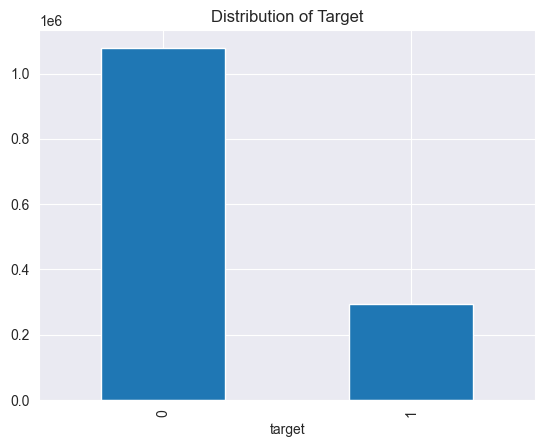

In [31]:
plt.figure()
df["target"].value_counts().plot(kind="bar")
plt.title('Distribution of Target')
plt.savefig("../../output/plots/eda/lc/target_distribution.png")
plt.show()
plt.close()

Loan Amount

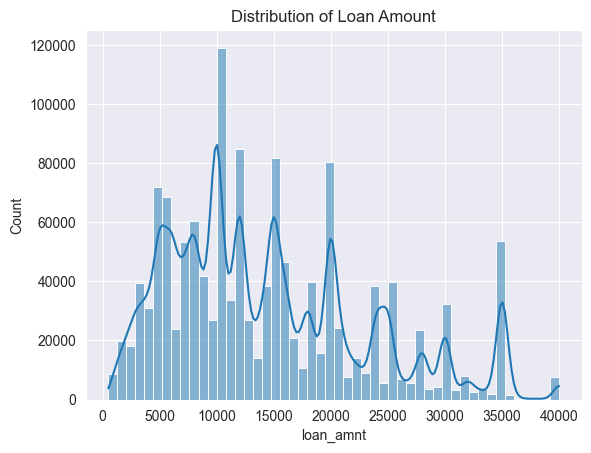

In [32]:
plt.figure()
sns.histplot(df["loan_amnt"], kde=True, bins=50)
plt.title('Distribution of Loan Amount')
plt.savefig("../../output/plots/eda/lc/loan_amount_distribution.png")
plt.show()
plt.close()

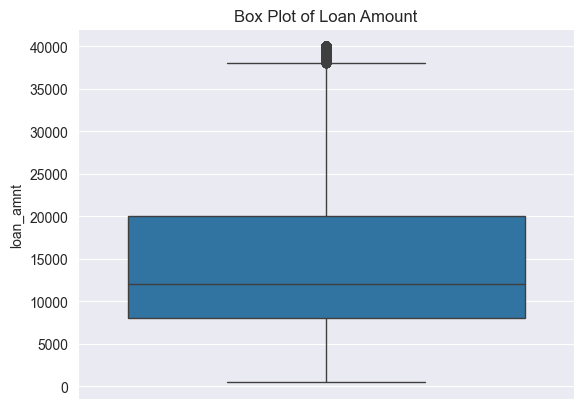

In [33]:
plt.figure()
sns.boxplot(df["loan_amnt"])
plt.title('Box Plot of Loan Amount')
plt.savefig("../../output/plots/eda/lc/loan_amount_box_plot.png")
plt.show()
plt.close()

In [34]:
skewness_value = df["loan_amnt"].skew()
print(f"Skewness of Loan Amount: {skewness_value}")

Skewness of Loan Amount: 0.7807786196213555


Log Income

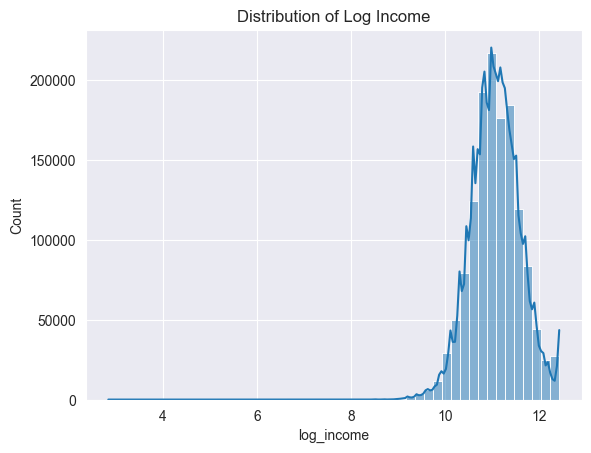

In [35]:
plt.figure()
sns.histplot(df["log_income"], kde=True, bins=50)
plt.title('Distribution of Log Income')
plt.savefig("../../output/plots/eda/lc/log_income_distribution.png")
plt.show()
plt.close()

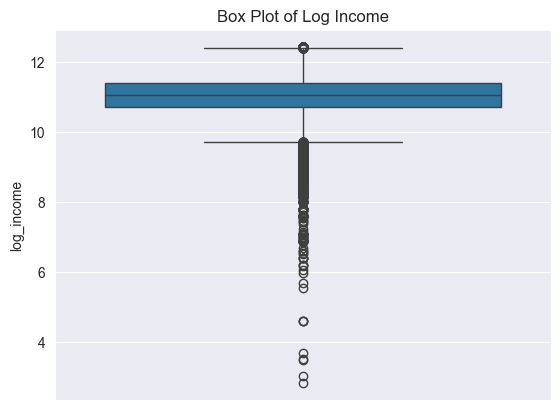

In [36]:
plt.figure()
sns.boxplot(df["log_income"])
plt.title('Box Plot of Log Income')
plt.savefig("../../output/plots/eda/lc/log_income_box_plot.png")
plt.show()
plt.close()

In [37]:
skewness_value = df["log_income"].skew()
print(f"Skewness of Log Income: {skewness_value}")

Skewness of Log Income: -0.07744563715314125


Credit Score Normalised

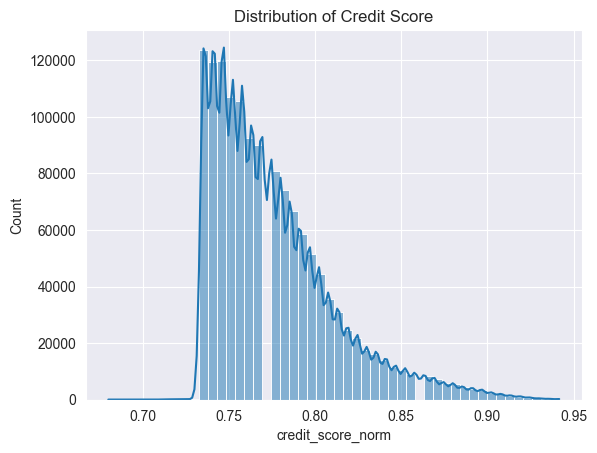

In [38]:
plt.figure()
sns.histplot(df["credit_score_norm"], kde=True, bins=50)
plt.title('Distribution of Credit Score')
plt.savefig("../../output/plots/eda/lc/credit_score_distribution.png")
plt.show()
plt.close()

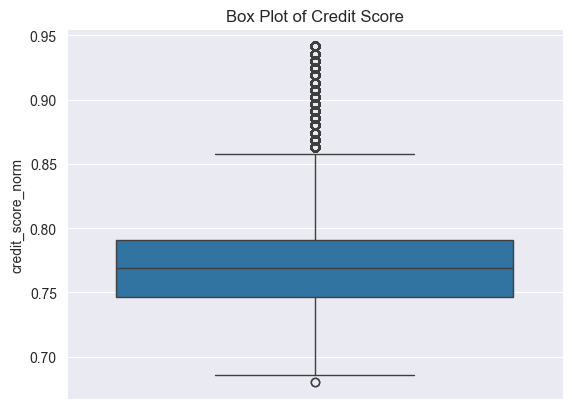

In [39]:
plt.figure()
sns.boxplot(df["credit_score_norm"])
plt.title('Box Plot of Credit Score')
plt.savefig("../../output/plots/eda/lc/credit_score_box_plot.png")
plt.show()
plt.close()

In [40]:
skewness_value = df["credit_score_norm"].skew()
print(f"Skewness of Credit Score: {skewness_value}")

Skewness of Credit Score: 1.2865318244215136


Credit History Length

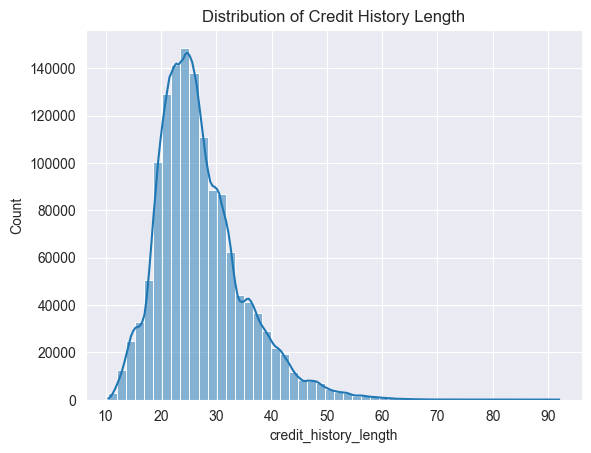

In [41]:
plt.figure()
sns.histplot(df["credit_history_length"], kde=True, bins=50)
plt.title('Distribution of Credit History Length')
plt.savefig("../../output/plots/eda/lc/credit_history_length_distribution.png")
plt.show()
plt.close()

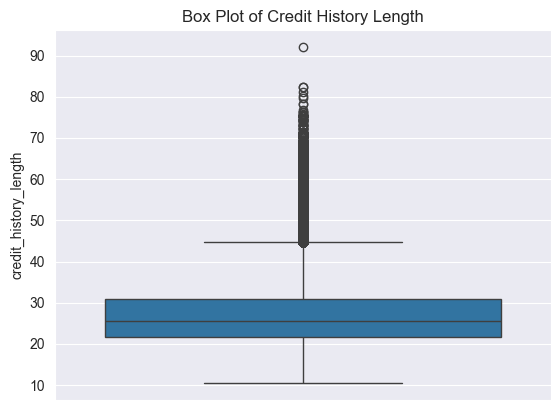

In [42]:
plt.figure()
sns.boxplot(df["credit_history_length"])
plt.title('Box Plot of Credit History Length')
plt.savefig("../../output/plots/eda/lc/credit_history_length_box_plot.png")
plt.show()
plt.close()

In [43]:
skewness_value = df["credit_history_length"].skew()
print(f"Skewness of Credit History Length: {skewness_value}")

Skewness of Credit History Length: 1.012045003888051


Revolving Line Utilization

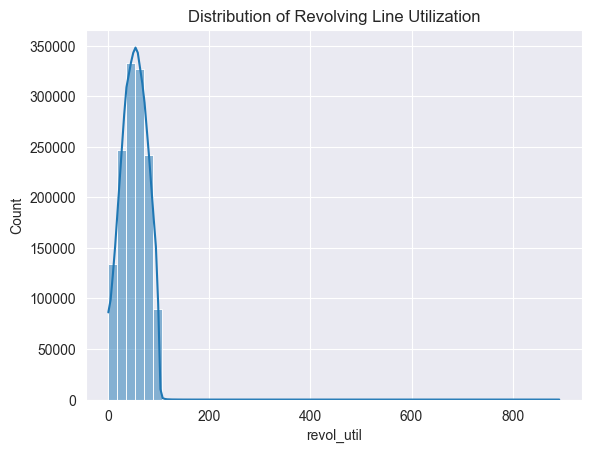

In [44]:
plt.figure()
sns.histplot(df["revol_util"], kde=True, bins=50)
plt.title('Distribution of Revolving Line Utilization')
plt.savefig("../../output/plots/eda/lc/revol_util_distribution.png")
plt.show()
plt.close()

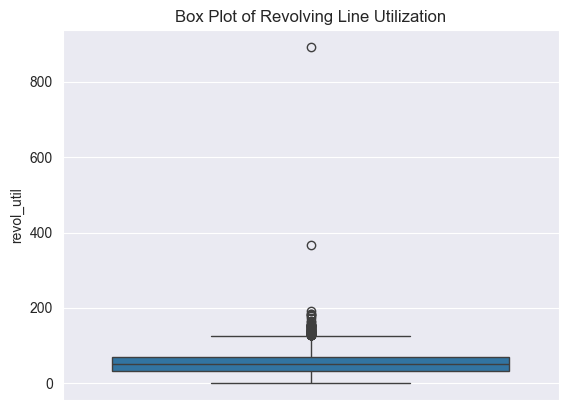

In [45]:
plt.figure()
sns.boxplot(df["revol_util"])
plt.title('Box Plot of Revolving Line Utilization')
plt.savefig("../../output/plots/eda/lc/revol_util_box_plot.png")
plt.show()
plt.close()

In [46]:
skewness_value = df["revol_util"].skew()
print(f"Skewness of Revolving Line Utilization: {skewness_value}")

Skewness of Revolving Line Utilization: -0.03590132418374888


# Feature vs Target

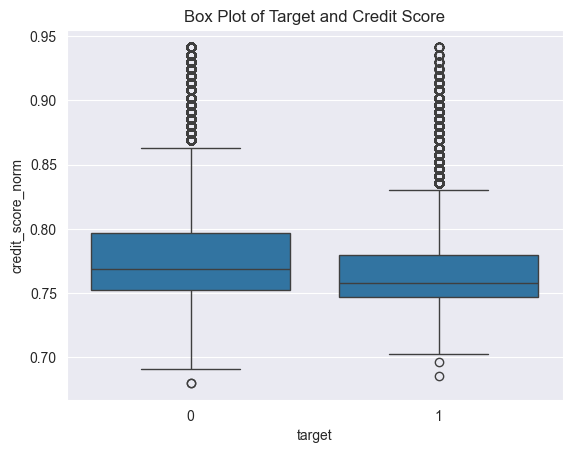

In [47]:
plt.figure()
sns.boxplot(x="target", y="credit_score_norm", data=df)
plt.title('Box Plot of Target and Credit Score')
plt.savefig("../../output/plots/eda/lc/target_credit_score_box_plot.png")
plt.show()
plt.close()

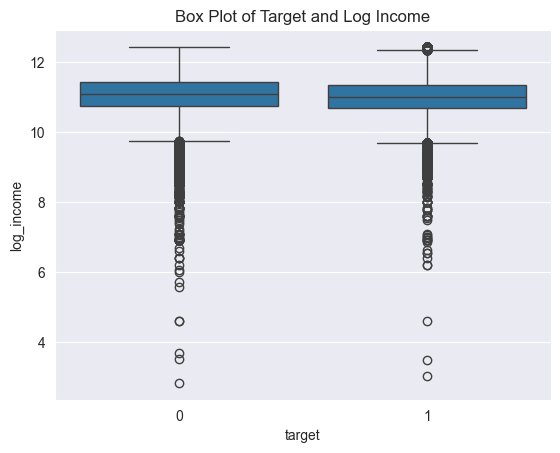

In [48]:
plt.figure()
sns.boxplot(x="target", y="log_income", data=df)
plt.title('Box Plot of Target and Log Income')
plt.savefig("../../output/plots/eda/lc/target_log_income_box_plot.png")
plt.show()
plt.close()

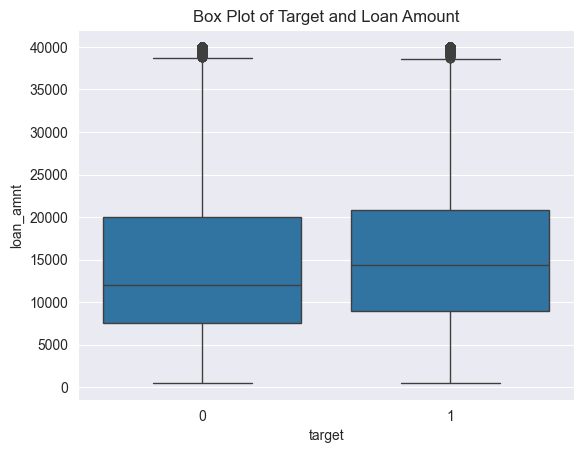

In [49]:
plt.figure()
sns.boxplot(x="target", y="loan_amnt", data=df)
plt.title('Box Plot of Target and Loan Amount')
plt.savefig("../../output/plots/eda/lc/target_loan_amnt_box_plot.png")
plt.show()
plt.close()

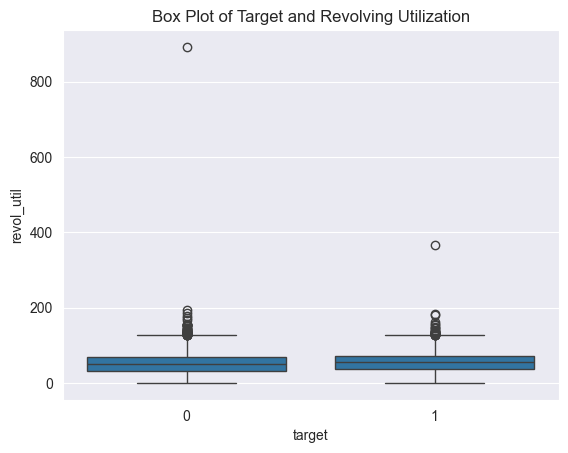

In [50]:
plt.figure()
sns.boxplot(x="target", y="revol_util", data=df)
plt.title('Box Plot of Target and Revolving Utilization')
plt.savefig("../../output/plots/eda/lc/target_revol_util_box_plot.png")
plt.show()
plt.close()

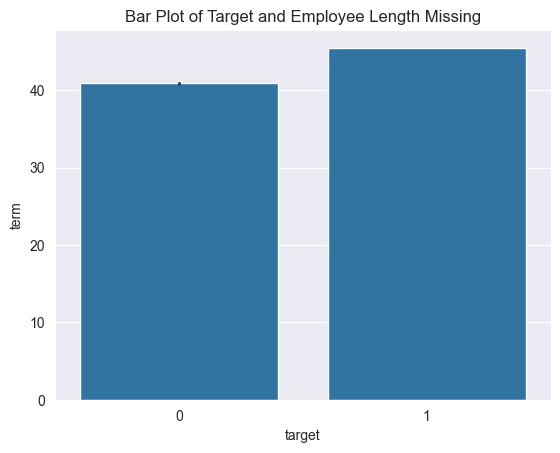

In [51]:
plt.figure()
sns.barplot(x="target", y="term", data=df)
plt.title('Bar Plot of Target and Employee Length Missing')
plt.savefig("../../output/plots/eda/lc/target_term_plot.png")
plt.show()
plt.close()

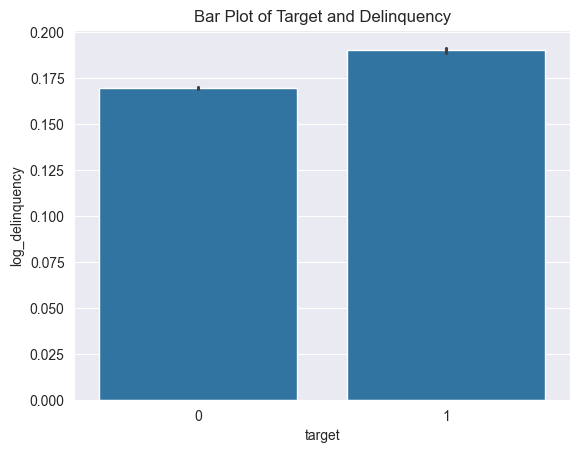

In [52]:
plt.figure()
sns.barplot(x="target", y="log_delinquency", data=df)
plt.title('Bar Plot of Target and Delinquency')
plt.savefig("../../output/plots/eda/lc/target_delinquency_bar_plot.png")
plt.show()
plt.close()

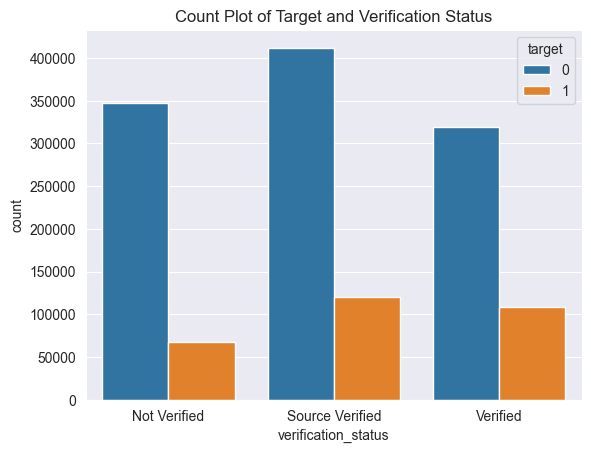

In [53]:
plt.figure()
sns.countplot(x="verification_status", hue="target", data=df_original)
plt.title('Count Plot of Target and Verification Status')
plt.savefig("../../output/plots/eda/lc/target_verification_status_box_plot.png")
plt.show()
plt.close()

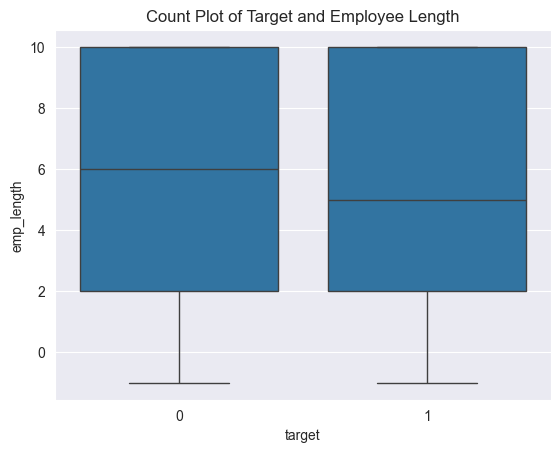

In [54]:
plt.figure()
sns.boxplot(x="target", y="emp_length", data=df)
plt.title('Count Plot of Target and Employee Length')
plt.savefig("../../output/plots/eda/lc/target_emp_length_box_plot.png")
plt.show()
plt.close()

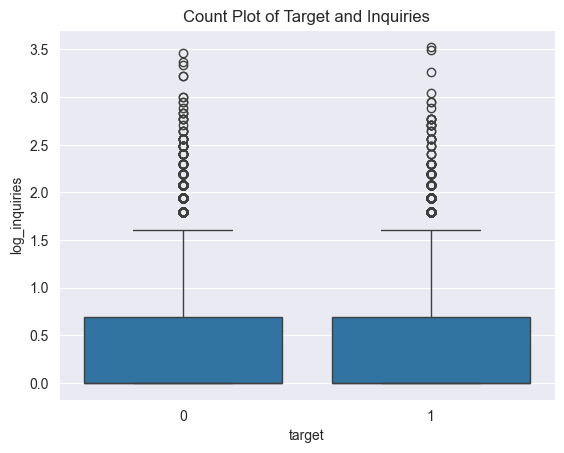

In [55]:
plt.figure()
sns.boxplot(x="target", y="log_inquiries", data=df)
plt.title('Count Plot of Target and Inquiries')
plt.savefig("../../output/plots/eda/lc/target_inquiries_box_plot.png")
plt.show()
plt.close()

# Correlation Analysis and Identifying Multicollinearity

In [56]:
numeric_lc = df.select_dtypes(include=["int64","float64"])
numeric_lc.columns

Index(['int_rate', 'loan_amnt', 'term', 'installment', 'annual_inc',
       'emp_length', 'revol_util', 'revol_bal', 'total_acc', 'open_acc',
       'target', 'fico_score', 'credit_history_length', 'credit_score_norm',
       'log_delinquency', 'log_loan_amount', 'log_installment', 'log_income',
       'log_credit_history_length', 'log_inquiries', 'inquiries',
       'log_loan_to_income', 'log_dti'],
      dtype='object')

In [57]:
corr_lc = numeric_lc.corr()
print("LendingClub Correlation Coefficient:", corr_lc)

LendingClub Correlation Coefficient:                            int_rate  loan_amnt      term  installment  \
int_rate                   1.000000   0.142508  0.416553     0.155678   
loan_amnt                  0.142508   1.000000  0.381966     0.953027   
term                       0.416553   0.381966  1.000000     0.143445   
installment                0.155678   0.953027  0.143445     1.000000   
annual_inc                -0.107064   0.472191  0.085768     0.455241   
emp_length                -0.006920   0.115251  0.070191     0.100457   
revol_util                 0.240243   0.106221  0.062578     0.124921   
revol_bal                 -0.012891   0.347514  0.103957     0.335318   
total_acc                 -0.043273   0.207645  0.098433     0.184665   
open_acc                  -0.004299   0.185725  0.071213     0.176062   
target                     0.263599   0.072881  0.181947     0.057836   
fico_score                -0.403224   0.101585 -0.001837     0.051451   
credit_history

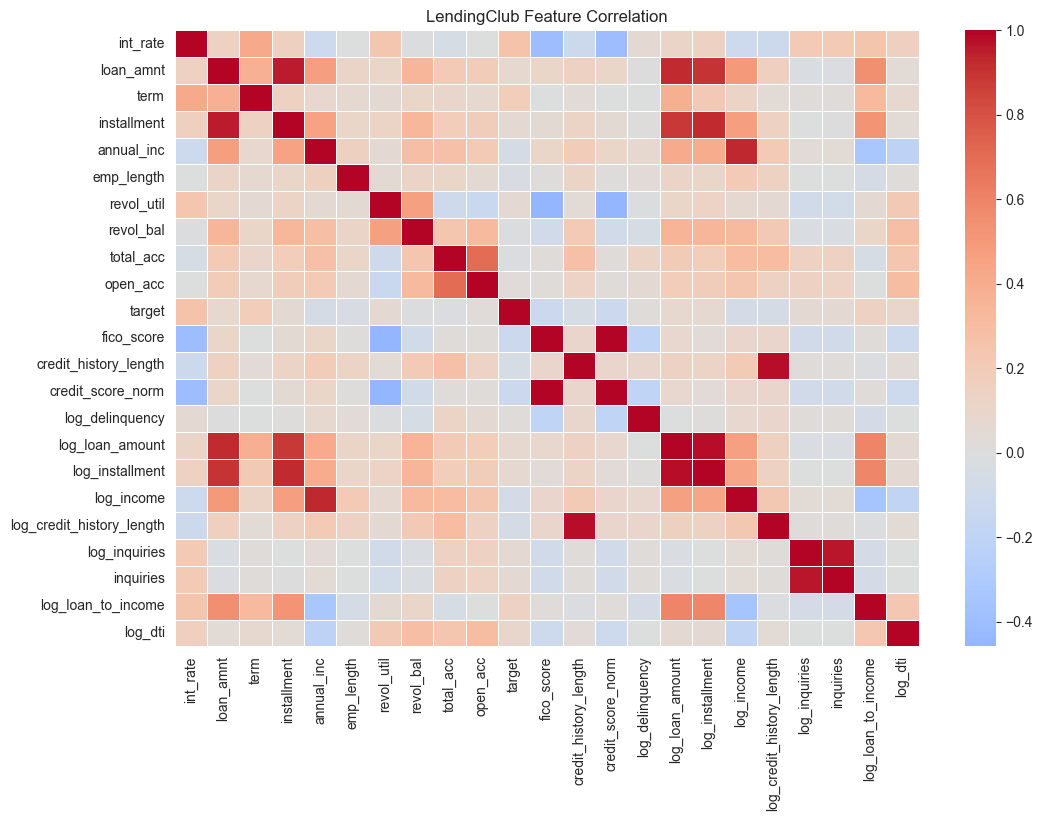

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_lc, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("LendingClub Feature Correlation")
plt.savefig("../../output/plots/eda/lc/correlation_heatmap.png")
plt.show()
plt.close()

In [59]:
corr_matrix = corr_lc.abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

print(high_corr)

['installment', 'credit_score_norm', 'log_loan_amount', 'log_installment', 'log_income', 'log_credit_history_length', 'inquiries']


In [60]:
upper[upper > 0.85]

,int_rate,loan_amnt,term,installment,annual_inc,emp_length,revol_util,revol_bal,total_acc,open_acc,...,credit_score_norm,log_delinquency,log_loan_amount,log_installment,log_income,log_credit_history_length,log_inquiries,inquiries,log_loan_to_income,log_dti
int_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,NaN,NaN,NaN,0.953027,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.923518,0.901744,NaN,NaN,NaN,NaN,NaN,NaN
term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.882999,0.920493,NaN,NaN,NaN,NaN,NaN,NaN
annual_inc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.930111,NaN,NaN,NaN,NaN,NaN
emp_length,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revol_util,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revol_bal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_acc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
open_acc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# df.drop(
#     columns=[
#         "inquiries",
#         "installment",
#         "credit_history_length",
#     ],
#     inplace=True,
#     errors="ignore"
# )

In [62]:
numeric_lc = df.select_dtypes(include=["int64","float64"])
corr_lc = numeric_lc.corr()

In [63]:
# Correlation with Default
corr_with_target = corr_lc["target"].sort_values(ascending=False)
print(corr_with_target)

target                       1.000000
int_rate                     0.263599
term                         0.181947
log_loan_to_income           0.139284
log_dti                      0.092386
log_loan_amount              0.075487
loan_amnt                    0.072881
log_installment              0.066823
log_inquiries                0.063044
inquiries                    0.061644
installment                  0.057836
revol_util                   0.054048
open_acc                     0.026799
log_delinquency              0.021676
revol_bal                   -0.009839
total_acc                   -0.016555
emp_length                  -0.033824
credit_history_length       -0.052789
log_credit_history_length   -0.058946
annual_inc                  -0.059597
log_income                  -0.063695
fico_score                  -0.129203
credit_score_norm           -0.129203
Name: target, dtype: float64


In [64]:
corr_lc.to_csv("../../output/tables/eda/lendingclub_correlations.csv")

# Outlier Detection and Treatment

Visual Outlier Detection in Lending Club dataset using Boxplots

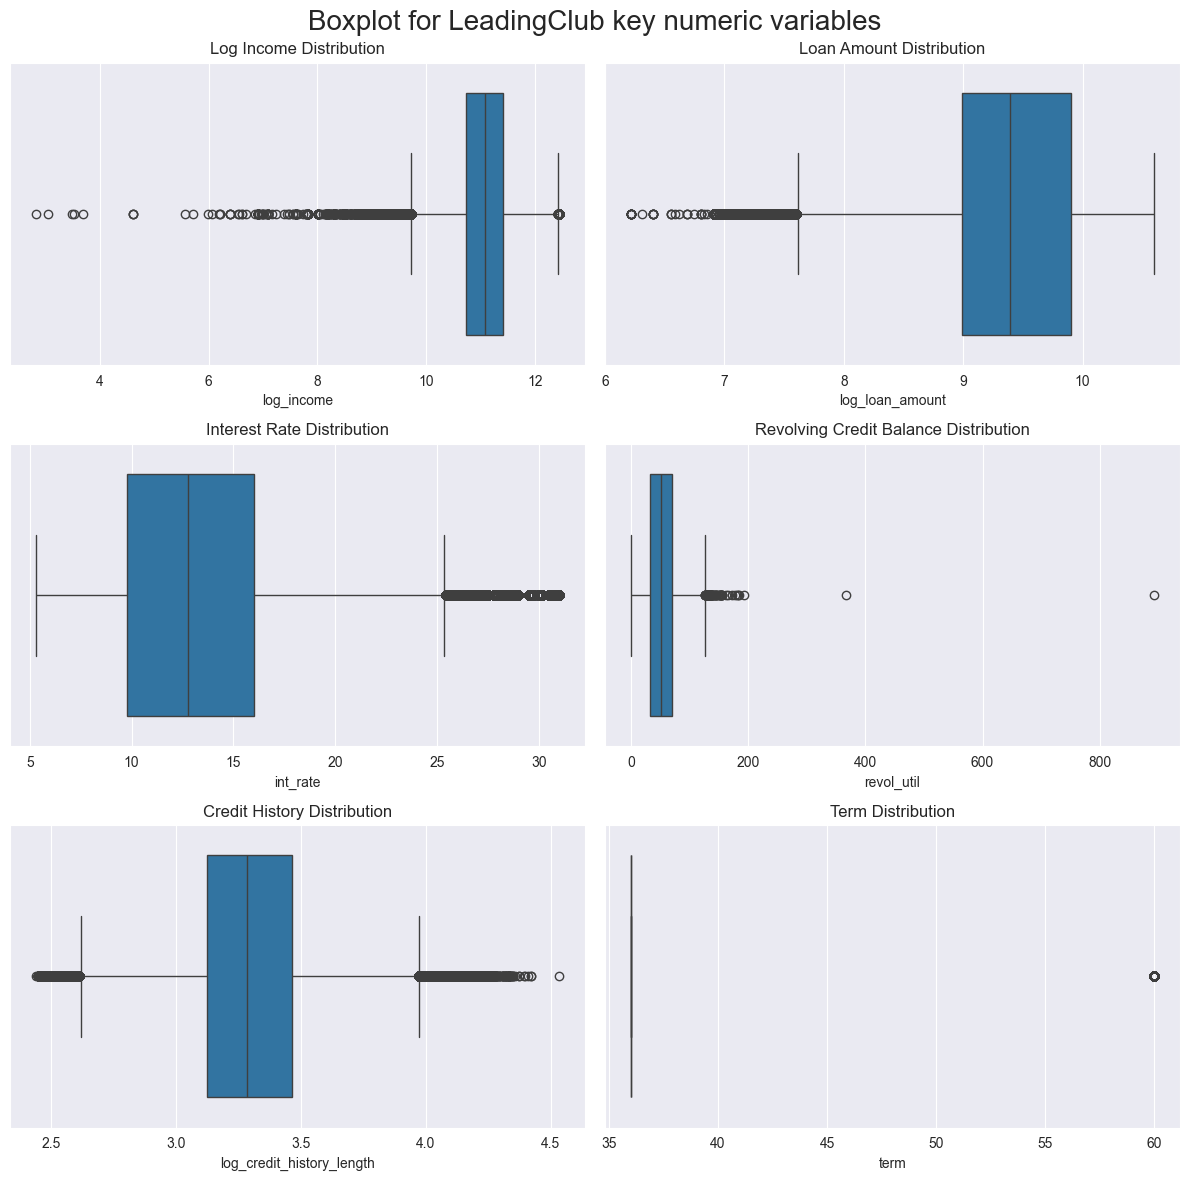

In [65]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Plot and set title for each
sns.boxplot(x=df["log_income"], ax=axes[0, 0]).set_title("Log Income Distribution")
sns.boxplot(x=df["log_loan_amount"], ax=axes[0, 1]).set_title("Loan Amount Distribution")
sns.boxplot(x=df["int_rate"], ax=axes[1, 0]).set_title("Interest Rate Distribution")
sns.boxplot(x=df["revol_util"], ax=axes[1, 1]).set_title("Revolving Credit Balance Distribution")
sns.boxplot(x=df["log_credit_history_length"], ax=axes[2, 0]).set_title("Credit History Distribution")
sns.boxplot(x=df["term"], ax=axes[2, 1]).set_title("Term Distribution")

# Add a Main Figure Title
plt.suptitle("Boxplot for LeadingClub key numeric variables", fontsize=20)
plt.savefig("../../output/plots/eda/lc/boxplot.png")
plt.tight_layout()
plt.show()
plt.close()

Statistical Outlier Detection

In [66]:
df["log_income"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     1.108087e+01
std      5.285932e-01
min      2.833213e+00
50%      1.108216e+01
90%      1.173608e+01
95%      1.195119e+01
99%      1.243719e+01
max      1.243719e+01
Name: log_income, dtype: float64

In [67]:
df["log_loan_amount"].describe(percentiles=[0.90,0.95,0.99])


count    1.373508e+06
mean     9.369440e+00
std      6.970657e-01
min      6.216606e+00
50%      9.392745e+00
90%      1.024000e+01
95%      1.040429e+01
99%      1.046313e+01
max      1.059666e+01
Name: log_loan_amount, dtype: float64

<Axes: xlabel='log_loan_amount'>

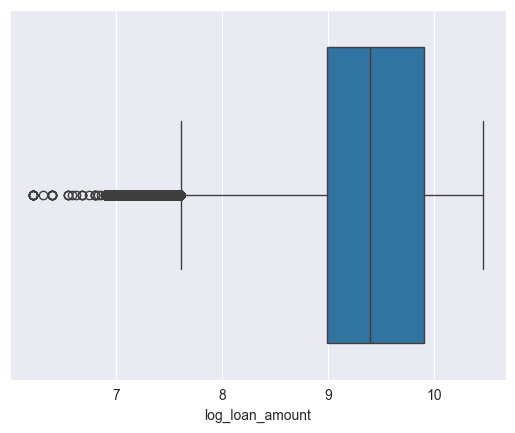

In [68]:
upper = df["log_loan_amount"].quantile(0.99)
df["log_loan_amount"] = df["log_loan_amount"].clip(upper=upper)
sns.boxplot(x=df["log_loan_amount"])

In [69]:
df["revol_util"].describe(percentiles=[0.90,0.95,0.99])


count    1.373508e+06
mean     5.177206e+01
std      2.453097e+01
min      0.000000e+00
50%      5.210000e+01
90%      8.500000e+01
95%      9.150000e+01
99%      9.820000e+01
max      8.923000e+02
Name: revol_util, dtype: float64

<Axes: xlabel='revol_util'>

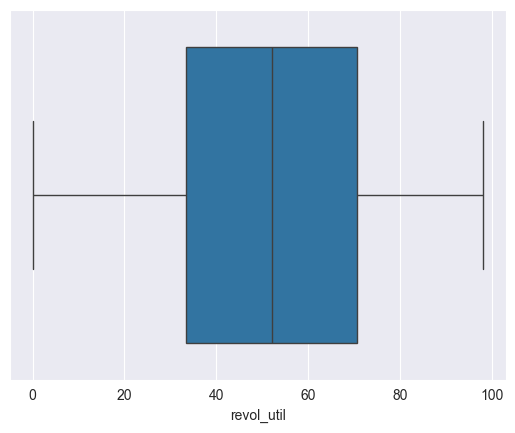

In [70]:
upper = df["revol_util"].quantile(0.99)
df["revol_util"] = df["revol_util"].clip(upper=upper)
sns.boxplot(x=df["revol_util"])

In [71]:
df["credit_score_norm"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     7.756554e-01
std      3.534180e-02
min      6.800000e-01
50%      7.688889e-01
90%      8.244444e-01
95%      8.466667e-01
99%      8.911111e-01
max      9.416667e-01
Name: credit_score_norm, dtype: float64

In [72]:
df["log_credit_history_length"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     3.298559e+00
std      2.614596e-01
min      2.440559e+00
50%      3.282969e+00
90%      3.648343e+00
95%      3.751404e+00
99%      3.943309e+00
max      4.532982e+00
Name: log_credit_history_length, dtype: float64

<Axes: xlabel='log_credit_history_length'>

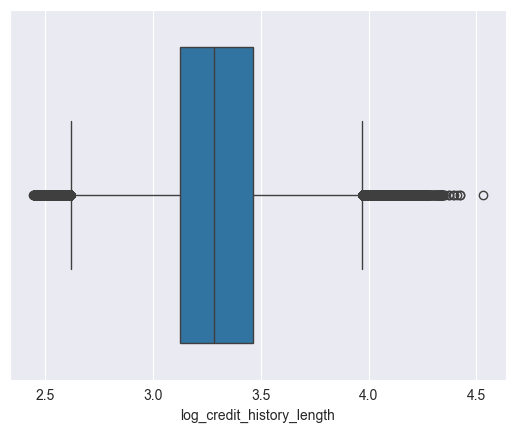

In [73]:
upper = df["log_credit_history_length"].quantile(0.99)
df["credit_history_length"] = df["log_credit_history_length"].clip(upper=upper)
sns.boxplot(x=df["log_credit_history_length"])

In [74]:
df["total_acc"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     2.494231e+01
std      1.200980e+01
min      1.000000e+00
50%      2.300000e+01
90%      4.100000e+01
95%      4.700000e+01
99%      6.100000e+01
max      1.760000e+02
Name: total_acc, dtype: float64

<Axes: xlabel='total_acc'>

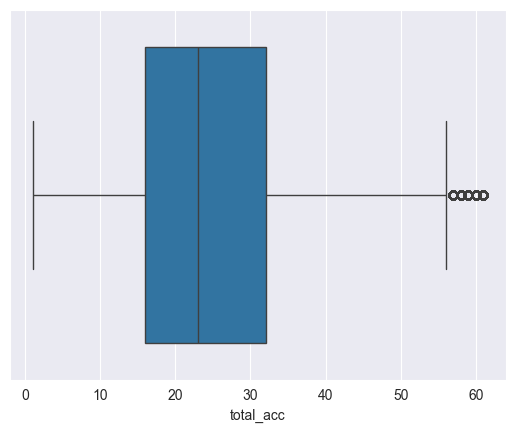

In [75]:
upper = df["total_acc"].quantile(0.99)
df["total_acc"] = df["total_acc"].clip(upper=upper)
sns.boxplot(x=df["total_acc"])

In [76]:
df["term"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     4.186296e+01
std      1.031197e+01
min      3.600000e+01
50%      3.600000e+01
90%      6.000000e+01
95%      6.000000e+01
99%      6.000000e+01
max      6.000000e+01
Name: term, dtype: float64

In [77]:
df["int_rate"].describe(percentiles=[0.90,0.95,0.99])

count    1.373508e+06
mean     1.328534e+01
std      4.787062e+00
min      5.310000e+00
50%      1.279000e+01
90%      1.952000e+01
95%      2.235000e+01
99%      2.649000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

In [78]:
df.to_csv('../../data/processed/featured_lending-club-car-loan.csv')